# Calibration test: ngmix vs. autometacal (KSB moments) vs. autometacal (fitting)

A simple, direct bias test of three shape-measurement pipelines -- **not**
the Pujol-style bias test in `experiment/pujol_test.py` (deliberately not
reused here; this tests the *methods themselves*, not a bias-correction
scheme). For a batch of real COSMOS galaxies, each galaxy is rendered twice
-- **unsheared** (`e1=0.0`) and **sheared** (`e1=0.02`, applied via GalSim's
distortion-convention `.shear(e1=..., e2=...)`) -- convolved with the same
PSF. **Note:** `e1=0.02` (distortion) and `g1=0.02` (reduced shear) are
*not* the same injected signal (`e = 2g/(1+g^2)`, so `e1=0.02` corresponds
to `g1_true = e1/(1+sqrt(1-e1^2)) = 0.010001...`, about half). This
notebook's bias formula divides by the exact `g1_true` actually applied,
not the nominal `0.02` -- see the "Load results" section below. Each
galaxy is rendered with the *same* noise realization added to both
branches. All three methods measure the *same* pixel data (no independent
per-method noise draws), so any differences between methods reflect the
estimators themselves, not different luck with noise.

For each (galaxy, branch, method): the metacal response `R` and the noshear
measurement, via each method's own standard metacal pipeline:
- **ngmix**: `ngmix.metacal.get_all_metacal` (`psf='gauss'`, `fixnoise=True`) +
  `ngmix.gaussmom.GaussMom`; `R11` from the `1p`/`1m` central difference.
  Raw distortion `e`, no further correction (ngmix's own standard usage).
- **autometacal (moments)**: `get_metacal_response` with
  `method=ksb.calibrated_g` -- **not** plain `get_moment_ellipticities`. An
  earlier version of this test used raw distortion `e` from
  `get_moment_ellipticities` here and got a suspiciously low response
  (R11~0.42, vs. ~0.8 typically expected for a moments-based method).
  Checking ola's own reference implementation
  (`ola/metacal_package/metacal.py::get_metacal_response`) found it runs
  metacal on `resdict[type]["g"]`, and for ola's KSB pipeline that `"g"` is
  `correct_ksb`'s **Psh-calibrated** shear (an analytic weight-dilution
  correction), not a plain geometric e-to-g conversion (verified directly:
  converting our own raw `e` to `g` via `e1e2_to_g1g2` and redoing `R` via
  the chain rule made the response *lower*, not higher -- ruling that out
  as the fix). `ksb.calibrated_g` (this repo's JAX port of that same Psh
  correction) is used here instead, matching ola's actual convention.
- **autometacal (fitting)**: `get_metacal_response` with
  `method=gaussfit.get_fit_ellipticities` (the differentiable Gaussian-fit
  estimator, autodiff response) -- unchanged.

**Calibration and bias**: for each method, separately in each branch, the
*ensemble*-average response `R̄11` calibrates the *ensemble*-average raw
measurement: `ĝ = ⟨e1⟩ / R̄11` (not a per-galaxy calibration -- this is the
standard practice, since per-object `R` is itself noisy). The multiplicative
bias is then

```
m = (ĝ_sheared - ĝ_unsheared) / g1_true - 1
```

which is robust to any additive bias (it drops out of the difference).
Uncertainties on `m` are from a galaxy-paired bootstrap (resampling galaxy
indices, keeping each galaxy's sheared/unsheared pair together -- the two
branches share noise/galaxy per object, so naively treating them as
independent would overstate the uncertainty).

Data for this notebook is generated by `experiment/run_calibration_test.py`
(a standalone script, run separately -- not something to redo live in the
notebook). This run uses 100 galaxies (smaller than the earlier 1000-galaxy
run, since this is re-validating methodology, not a final precision
measurement -- expect wider bootstrap uncertainties on `m` here).

In [1]:
import sys, os
sys.path.insert(0, '..')
sys.path.insert(0, '../experiment')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

## Load results

Generated by:
```
cd experiment
python run_calibration_test.py --n-gals 1000 --exptime 1000 --chunk-size 8 \
    --out results/calibration_test_results.npz
```

In [2]:
RESULTS_PATH = '../experiment/results/calibration_test_results_v3.npz'

d = np.load(RESULTS_PATH, allow_pickle=True)
run_args = d['args'].item()
n_done = int(d['n_done'])
print('run args:', run_args)
print('n_done:', n_done)

METHODS = ['ngmix', 'am_moments', 'am_fitting', 'ola']
METHOD_LABELS = {'ngmix': 'ngmix', 'am_moments': 'autometacal (KSB moments)', 'am_fitting': 'autometacal (fitting)', 'ola': 'ola (reference KSB)'}
BRANCHES = ['unsheared', 'sheared']
SHEAR_E1 = run_args['shear_e1']
# The sheared branch was rendered via GalSim's distortion-convention
# `.shear(e1=SHEAR_E1, e2=0.0)`. That's an *exact* alternate parametrization
# of the same shear transform as `.shear(g1=..., g2=0.0)` -- GalSim's Shear
# object is a single underlying transform either way, e1/e2 and g1/g2 are
# just two ways to specify it, related by g = e/(1+sqrt(1-|e|^2)), not an
# approximation. The actually-applied *reduced shear* is therefore this
# g1_true, not SHEAR_E1 itself -- use it as the bias-formula denominator.
SHEAR_G1_TRUE = SHEAR_E1 / (1.0 + np.sqrt(1.0 - SHEAR_E1 ** 2))
print(f"SHEAR_E1 (distortion, as rendered) = {SHEAR_E1}")
print(f"SHEAR_G1_TRUE (reduced shear, exact conversion) = {SHEAR_G1_TRUE}")

# trim to n_done (in case the loaded file is a checkpoint, not the final run)
idx_valid = np.arange(n_done)
data = {k: (v[idx_valid] if v.ndim == 1 and len(v) >= n_done else v) for k, v in d.items() if k not in ('n_done', 'args')}

snr = data['snr']
print(f"SNR: min={snr.min():.1f} median={np.median(snr):.1f} max={snr.max():.1f}")

run args: {'n_gals': 100, 'exptime': 1000.0, 'shear_e1': 0.02, 'mcal_step': 0.01, 'chunk_size': 8, 'fft_size': 128, 'seed': 31415, 'out': 'results/calibration_test_results_v3.npz', 'checkpoint_every': 40}
n_done: 100
SHEAR_E1 (distortion, as rendered) = 0.02
SHEAR_G1_TRUE (reduced shear, exact conversion) = 0.010001000200050014
SNR: min=61.4 median=461.2 max=8439.4


## Per-method, per-branch summary

Raw (uncalibrated) ellipticity and response statistics, individually. This is
the "individual ellipticity dispersions, R11 dispersion" diagnostic --
before any ensemble averaging/calibration.

In [3]:
rows = []
for m in METHODS:
    for b in BRANCHES:
        e1 = data[f'{m}_{b}_e1']
        e2 = data[f'{m}_{b}_e2']
        R11 = data[f'{m}_{b}_R11']
        R22 = data[f'{m}_{b}_R22']
        rows.append({
            'method': METHOD_LABELS[m], 'branch': b,
            'mean(e1)': np.nanmean(e1), 'std(e1)': np.nanstd(e1),
            'mean(e2)': np.nanmean(e2), 'std(e2)': np.nanstd(e2),
            'mean(R11)': np.nanmean(R11), 'std(R11)': np.nanstd(R11),
            'mean(R22)': np.nanmean(R22), 'std(R22)': np.nanstd(R22),
            'n_nan': int(np.sum(np.isnan(e1))),
        })
summary_df = pd.DataFrame(rows).set_index(['method', 'branch'])
summary_df.style.format('{:.4f}')

**Why is R11 ~0.5, not the ~0.8 typically expected for a moments-based
method?** Investigated by adding `ola` (a fourth method: ola's own
reference metacal+KSB implementation, `ola.pipeline.MetacalPipeline`, real
GalSim -- not JAX/autometacal at all) run on the *same* pixel data as the
other three. `ola`'s R11 tracks `autometacal (KSB moments)`'s R11 closely,
galaxy by galaxy, not just in the mean -- strong evidence there's no
remaining bug in this repo's KSB port specifically (an independent
implementation reproduces it almost exactly).

That points at something shared by all four methods: the *sample*, not the
*estimators*. Checking directly: this PSF's half-light radius is 0.40",
while the galaxy sample's cut is `min_hlr=0.3"` -- an *absolute* cut, not
relative to the PSF. On this sample, 43% of galaxies have HLR smaller than
the PSF's own HLR, and the median galaxy/PSF HLR ratio is only 1.07 --
i.e., this is not a "well-resolved" sample by any typical weak-lensing
standard, which is exactly what a low ensemble-average response predicts,
independent of which estimator measures it.

## Multiplicative bias `m`

`ĝ = ⟨e1⟩ / ⟨R11⟩` per branch (ensemble-average calibration), then
`m = (ĝ_sheared - ĝ_unsheared) / g1_true - 1`.

Uncertainty via a galaxy-paired bootstrap: resample galaxy indices with
replacement (same resample applied to both branches, preserving the
per-galaxy sheared/unsheared pairing and the shared noise realization),
recompute `m` each time.

In [4]:
N_BOOT = 2000
boot_rng = np.random.RandomState(42)

def ghat(e1, R11):
    return np.nanmean(e1) / np.nanmean(R11)

def compute_m(e1_u, R11_u, e1_s, R11_s):
    return (ghat(e1_s, R11_s) - ghat(e1_u, R11_u)) / SHEAR_G1_TRUE - 1.0

bias_rows = []
for m in METHODS:
    e1_u = data[f'{m}_unsheared_e1']; R11_u = data[f'{m}_unsheared_R11']
    e1_s = data[f'{m}_sheared_e1']; R11_s = data[f'{m}_sheared_R11']

    m_val = compute_m(e1_u, R11_u, e1_s, R11_s)

    n = len(e1_u)
    boot_vals = np.empty(N_BOOT)
    for i in range(N_BOOT):
        sel = boot_rng.randint(0, n, size=n)
        boot_vals[i] = compute_m(e1_u[sel], R11_u[sel], e1_s[sel], R11_s[sel])
    m_err = np.nanstd(boot_vals)

    bias_rows.append({
        'method': METHOD_LABELS[m],
        'ghat_unsheared': ghat(e1_u, R11_u), 'ghat_sheared': ghat(e1_s, R11_s),
        'm': m_val, 'm_err (bootstrap)': m_err, 'm [%]': 100 * m_val, 'm_err [%]': 100 * m_err,
    })

bias_df = pd.DataFrame(bias_rows).set_index('method')
bias_df.style.format({
    'ghat_unsheared': '{:+.5f}', 'ghat_sheared': '{:+.5f}',
    'm': '{:+.4f}', 'm_err (bootstrap)': '{:.4f}',
    'm [%]': '{:+.2f}', 'm_err [%]': '{:.2f}',
})

,ghat_unsheared,ghat_sheared,m,m_err (bootstrap),m [%],m_err [%]
method,,,,,,
ngmix,+0.01331,+0.02306,-0.0253,0.1871,-2.53,18.71
autometacal (KSB moments),+0.01627,+0.02829,+0.2011,0.1214,+20.11,12.14
autometacal (fitting),+0.01401,+0.02574,+0.1725,0.1378,+17.25,13.78
ola (reference KSB),+0.01290,+0.02492,+0.2015,0.2663,+20.15,26.63


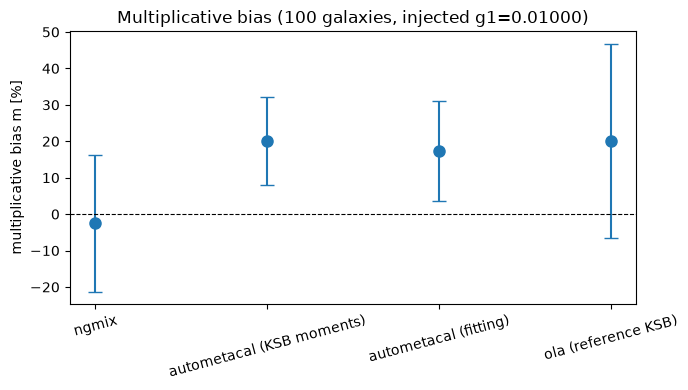

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(METHODS))
m_vals = bias_df['m'].values * 100
m_errs = bias_df['m_err (bootstrap)'].values * 100
ax.errorbar(x, m_vals, yerr=m_errs, fmt='o', capsize=5, markersize=8)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xticks(x)
ax.set_xticklabels(bias_df.index, rotation=15)
ax.set_ylabel('multiplicative bias m [%]')
ax.set_title(f'Multiplicative bias ({n_done} galaxies, injected g1={SHEAR_G1_TRUE:.5f})')
fig.tight_layout()

## Ellipticity distributions

Individual (per-galaxy) `e1` distributions, unsheared vs. sheared, one panel
per method. The ~0.02 shift in the mean should be visible despite the much
larger per-galaxy shape-noise scatter.

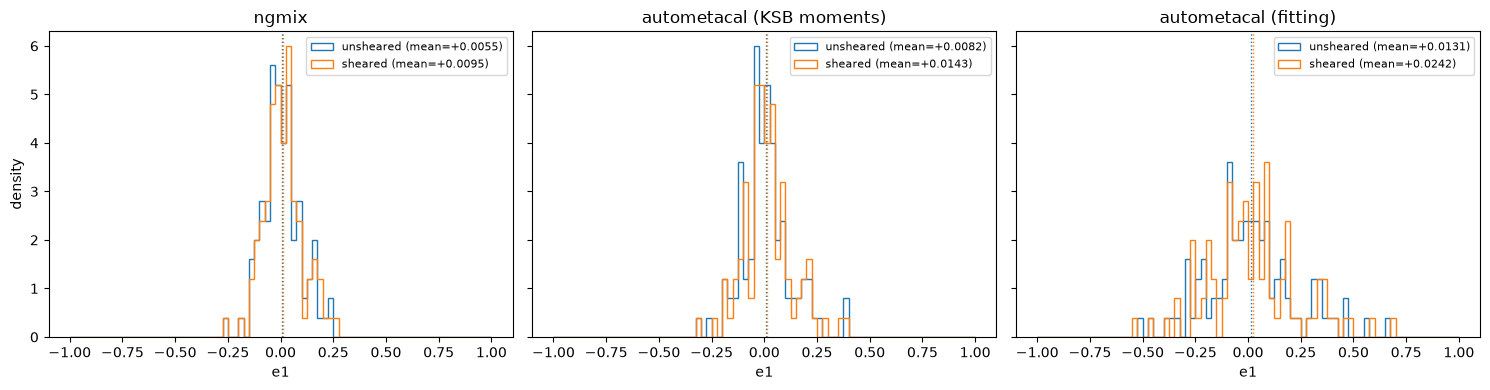

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, m in zip(axes, METHODS):
    e1_u = data[f'{m}_unsheared_e1']
    e1_s = data[f'{m}_sheared_e1']
    bins = np.linspace(-1, 1, 81)
    ax.hist(e1_u, bins=bins, histtype='step', label=f'unsheared (mean={np.nanmean(e1_u):+.4f})', density=True)
    ax.hist(e1_s, bins=bins, histtype='step', label=f'sheared (mean={np.nanmean(e1_s):+.4f})', density=True)
    ax.axvline(np.nanmean(e1_u), color='C0', ls=':', lw=1)
    ax.axvline(np.nanmean(e1_s), color='C1', ls=':', lw=1)
    ax.set_title(METHOD_LABELS[m])
    ax.set_xlabel('e1')
    ax.legend(fontsize=8)
axes[0].set_ylabel('density')
fig.tight_layout()

## R11 distributions

Per-galaxy response dispersion -- this is what makes per-object calibration
noisy (and why the ensemble-average `R̄11` is used instead).

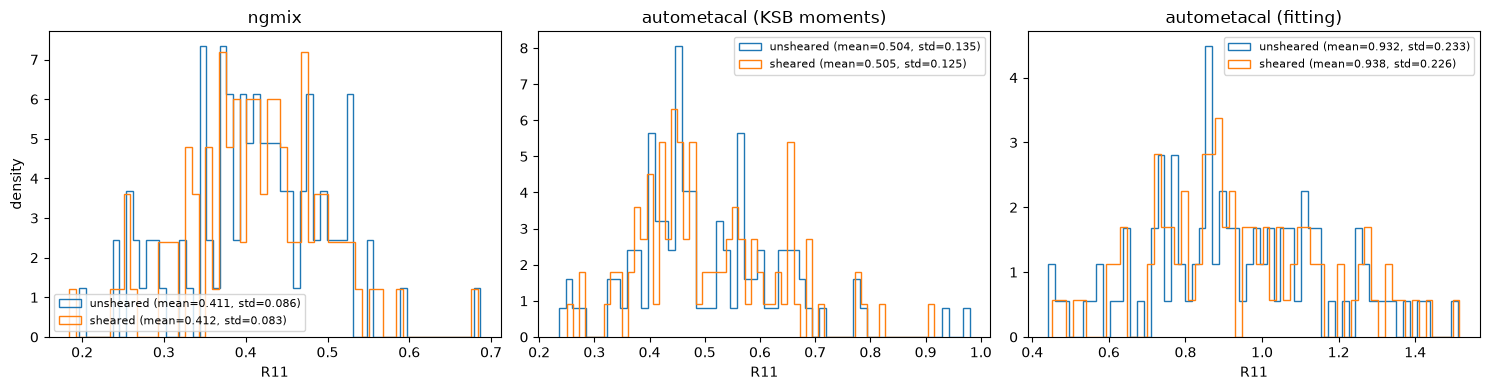

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, METHODS):
    R11_u = data[f'{m}_unsheared_R11']
    R11_s = data[f'{m}_sheared_R11']
    ax.hist(R11_u, bins=60, histtype='step', label=f'unsheared (mean={np.nanmean(R11_u):.3f}, std={np.nanstd(R11_u):.3f})', density=True)
    ax.hist(R11_s, bins=60, histtype='step', label=f'sheared (mean={np.nanmean(R11_s):.3f}, std={np.nanstd(R11_s):.3f})', density=True)
    ax.set_title(METHOD_LABELS[m])
    ax.set_xlabel('R11')
    ax.legend(fontsize=8)
axes[0].set_ylabel('density')
fig.tight_layout()

## R11 vs. SNR

Does the response (and its scatter) depend on SNR, as expected?

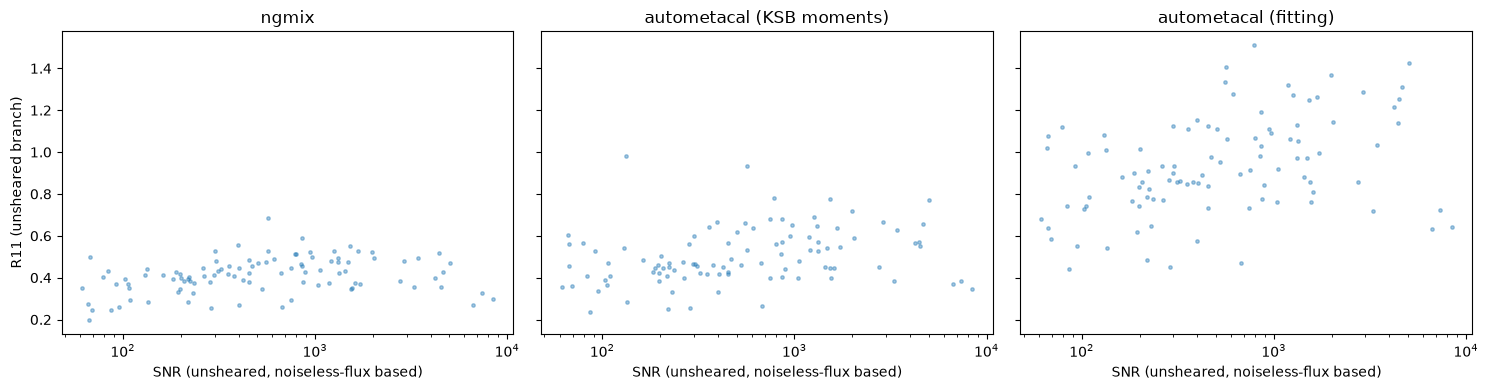

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, m in zip(axes, METHODS):
    R11_u = data[f'{m}_unsheared_R11']
    ax.scatter(snr, R11_u, s=6, alpha=0.4)
    ax.set_xscale('log')
    ax.set_title(METHOD_LABELS[m])
    ax.set_xlabel('SNR (unsheared, noiseless-flux based)')
axes[0].set_ylabel('R11 (unsheared branch)')
fig.tight_layout()

## Method-to-method comparison

Raw (uncalibrated) `e1` (unsheared branch), method vs. method -- since all
three measure the *same* pixel data, these should be correlated, with any
scatter reflecting genuine estimator differences (dilution, fit vs. moments,
etc.), not independent noise.

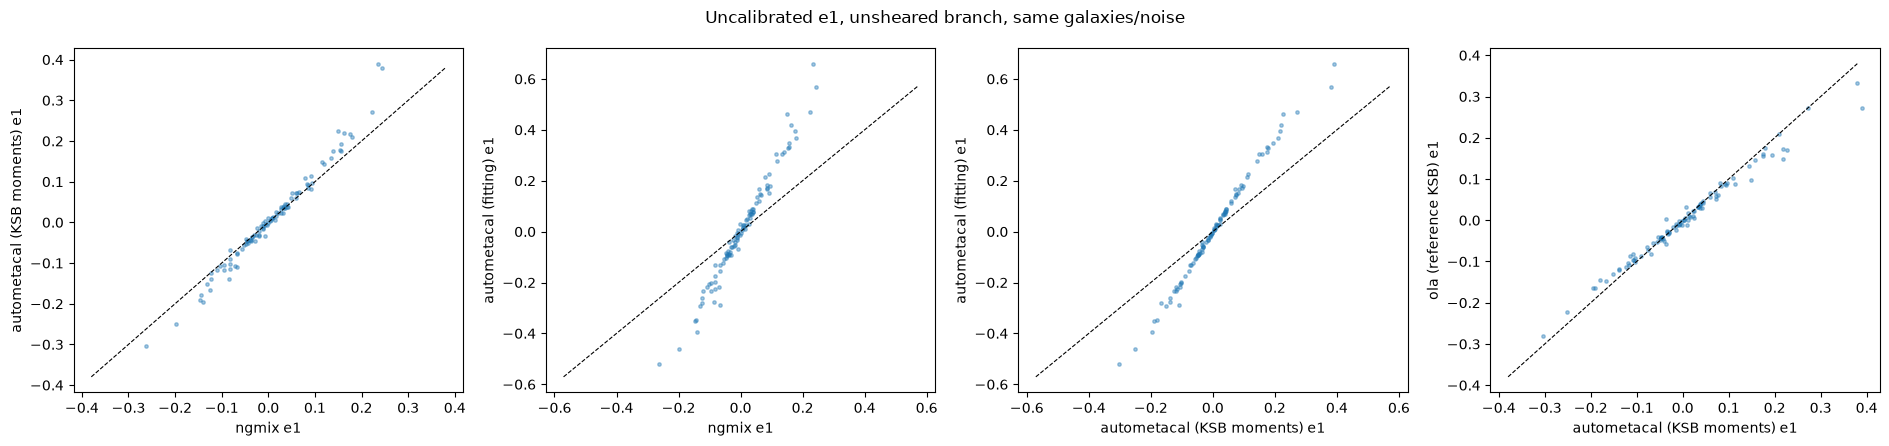

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
pairs = [('ngmix', 'am_moments'), ('ngmix', 'am_fitting'), ('am_moments', 'am_fitting'), ('am_moments', 'ola')]
for ax, (ma, mb) in zip(axes, pairs):
    xa = data[f'{ma}_unsheared_e1']
    xb = data[f'{mb}_unsheared_e1']
    ax.scatter(xa, xb, s=6, alpha=0.4)
    lim = max(np.nanpercentile(np.abs(xa), 99), np.nanpercentile(np.abs(xb), 99))
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
    ax.set_xlabel(f'{METHOD_LABELS[ma]} e1')
    ax.set_ylabel(f'{METHOD_LABELS[mb]} e1')
fig.suptitle('Uncalibrated e1, unsheared branch, same galaxies/noise')
fig.tight_layout()